# DL053 Transformer块与位置

先读lecture.pdf，完成lab.pdf练习，再Run All。代码重算6配置对齐、两个SGD更新与7幅图，不下载数据。每一节都说明shape与观察范围。

In [1]:
from pathlib import Path
import sys, json
# Jupyter启动目录可能是课程根或单元目录；寻找本单元而非误导入其他课。
candidates=[Path.cwd(),Path.cwd()/"units"/"053"]
ROOT=next((p.resolve() for p in candidates if (p/"experiment.py").exists() and p.name=="053"),None)
if ROOT is None:
    raise RuntimeError("请从units/053或课程根目录启动Notebook")
sys.path.insert(0,str(ROOT))
from experiment import Block, Norm, hand_ledger, run, setup, sinusoidal, rotate_pairs
import torch
setup()
REPLAY=ROOT/"notebook_replay"
print("torch",torch.__version__,"CPU float64 单线程")

torch 2.7.1+cpu CPU float64 单线程


## 1 拆头之前先标号
原shape为B=1,L=3,D=8。打印每头位置，合头要先把H、L轴换回。

In [2]:
x=torch.arange(24).reshape(1,3,8)
heads=x.reshape(1,3,2,4).transpose(1,2)
print(heads)
print("正确合头",torch.equal(heads.transpose(1,2).reshape_as(x),x))
print("错误合头",torch.equal(heads.reshape_as(x),x))

tensor([[[[ 0,  1,  2,  3],
          [ 8,  9, 10, 11],
          [16, 17, 18, 19]],

         [[ 4,  5,  6,  7],
          [12, 13, 14, 15],
          [20, 21, 22, 23]]]])
正确合头 True
错误合头 False


## 2 完整前向与两步同步SGD
每一步打印两次LN和残差后的输出。loss是四个标量的half-MSE；观察总体下降是否意味着每个坐标都改进。

In [3]:
ledger=hand_ledger()
for record in ledger:
    print("step",record["step"],"loss",record["loss"])
    print("output",record["out"])
print("首次fc2梯度",ledger[0]["gradients"]["fc2.weight"])
print("首次output梯度",ledger[0]["output_gradient"])
print(json.dumps(ledger[0]["backward_trace"],indent=2))
print("显式链式法则对齐误差",[r["manual_autograd_max"] for r in ledger])

step 0 loss 0.7934454500595015
output [[[0.11162186105496719, 4.088377858517172], [3.0883778585171724, -0.8883781389450328]]]
step 1 loss 0.5929251944797175
output [[[0.14048184718525727, 3.816973773144502], [2.9219028107558906, -0.7565500126723792]]]
step 2 loss 0.46225738659943466
output [[[0.1489650935421422, 3.612959565442599], [2.7892865004128318, -0.671756469425301]]]
首次fc2梯度 [[0.2720940831149504, 0.027905426136392218], [-0.22209422332878234, 0.522093732580125]]
首次output梯度 [[[0.027905465263741797, 0.5220944646292931], [0.2720944646292931, -0.2220945347362582]]]
{
  "GY": [
    [
      [
        0.027905465263741797,
        0.5220944646292931
      ],
      [
        0.2720944646292931,
        -0.2220945347362582
      ]
    ]
  ],
  "GU": [
    [
      [
        0.00558109305274836,
        0.10441889292585863
      ],
      [
        0.05441889292585862,
        -0.044418906947251646
      ]
    ]
  ],
  "Gpre": [
    [
      [
        0.0,
        0.10441889292585863
      ],

## 3 官方参考及结构干预
run重新复制参数、分别反向传播，并重算排列、位置、未来、长度与RoPE检查。对齐不是学习质量评测。

In [4]:
results=run(REPLAY)
print(json.dumps(results["alignment"],indent=2))

{
  "output": "/workspace/scratch/1577d0a62398/dl-course-production/units/053/notebook_replay",
  "alignment_max": 1.7763568394002505e-15,
  "structure": {
    "permutation_no_position_max": 1.1102230246251565e-16,
    "permutation_fixed_positions_max": 1.6193106802135262,
    "permutation_tokens_and_positions_max": 4.440892098500626e-16,
    "causal_future_change_max": 0.0,
    "bidirectional_future_change_max": 0.3330605305598836,
    "causal_prefix_extension_max": 1.1102230246251565e-16,
    "bidirectional_prefix_extension_max": 0.22876540480804897,
    "rope_joint_shift_max": 8.881784197001252e-16,
    "rope_norm_max": 2.220446049250313e-16,
    "parameter_count": 163,
    "causal_permuted_mask_max": 1.1102230246251565e-16,
    "causal_fixed_mask_max": 0.7897203113898941
  }
}
[
  {
    "seed": 5301,
    "pre": true,
    "output_max": 4.440892098500626e-16,
    "input_gradient_max": 6.661338147750939e-16,
    "parameter_gradient_max": 1.7763568394002505e-15
  },
  {
    "seed": 530

## 4 独立测试
unittest在普通模式和python -O中均有效。这里重跑全部6类测试，不用本单元保存的结果代替计算。

In [5]:
import unittest
from test_experiment import Tests
suite=unittest.defaultTestLoader.loadTestsFromTestCase(Tests)
outcome=unittest.TextTestRunner(verbosity=2).run(suite)
if not outcome.wasSuccessful():
    raise RuntimeError("DL053 tests failed")

test_different_lengths_and_masks (test_experiment.Tests.test_different_lengths_and_masks) ... 

ok


test_hand (test_experiment.Tests.test_hand) ... 

ok


test_manual_norm (test_experiment.Tests.test_manual_norm) ... 

...

ok


test_split_merge (test_experiment.Tests.test_split_merge) ... 

ok


----------------------------------------------------------------------
Ran 6 tests in 0.163s

OK


{
  "output": "/tmp/tmpdilexh8r",
  "alignment_max": 1.7763568394002505e-15,
  "structure": {
    "permutation_no_position_max": 1.1102230246251565e-16,
    "permutation_fixed_positions_max": 1.6193106802135262,
    "permutation_tokens_and_positions_max": 4.440892098500626e-16,
    "causal_future_change_max": 0.0,
    "bidirectional_future_change_max": 0.3330605305598836,
    "causal_prefix_extension_max": 1.1102230246251565e-16,
    "bidirectional_prefix_extension_max": 0.22876540480804897,
    "rope_joint_shift_max": 8.881784197001252e-16,
    "rope_norm_max": 2.220446049250313e-16,
    "parameter_count": 163,
    "causal_permuted_mask_max": 1.1102230246251565e-16,
    "causal_fixed_mask_max": 0.7897203113898941
  }
}


## 5 重新画图并嵌入实际图片
图由本次results.json和公式重绘。需要Noto Sans CJK；缺字体时按lab.pdf安装并设置DL_CJK_FONT。

Rendered 7 figures
01_architecture.png


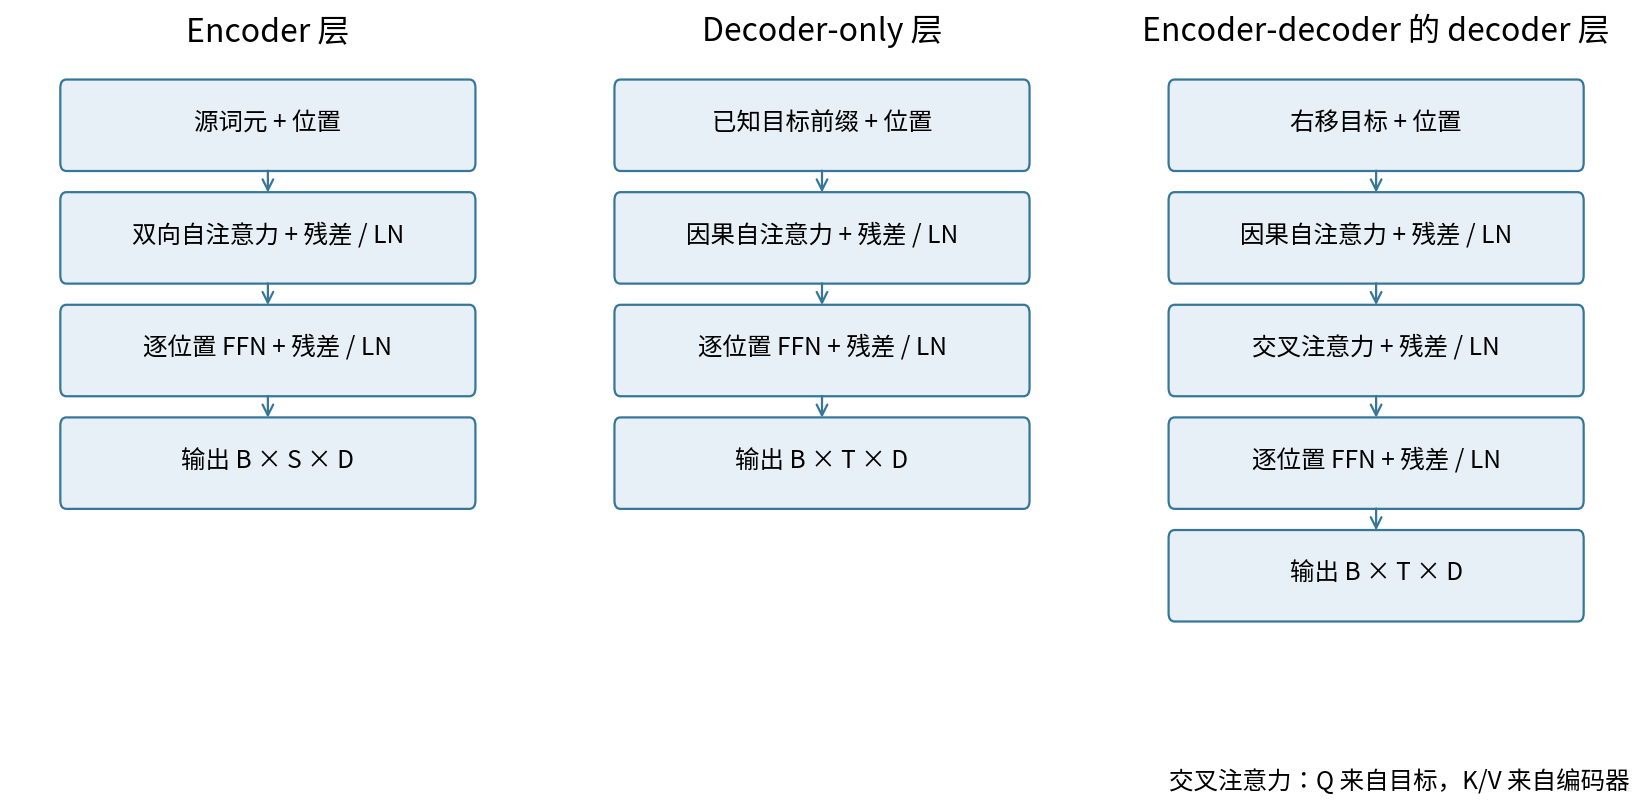

02_heads.png


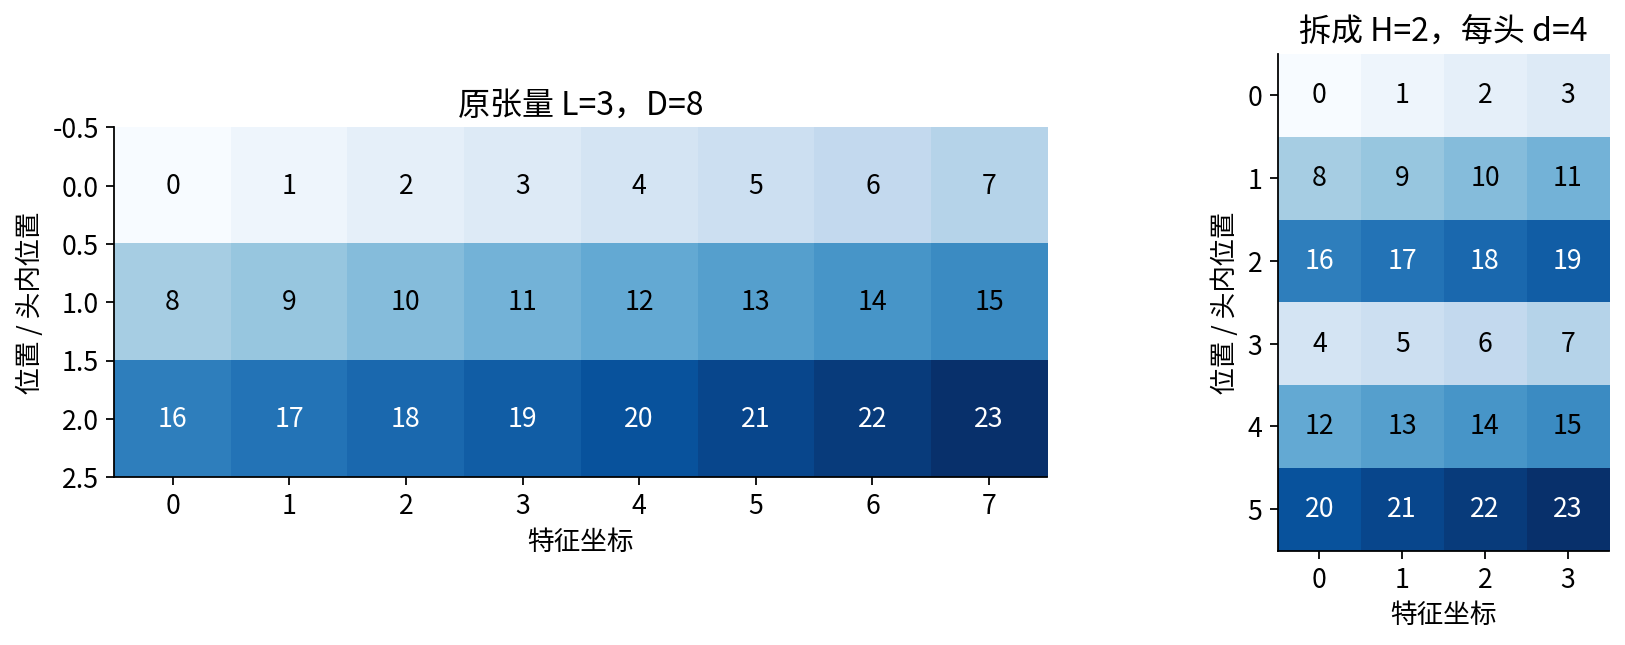

03_norm.png


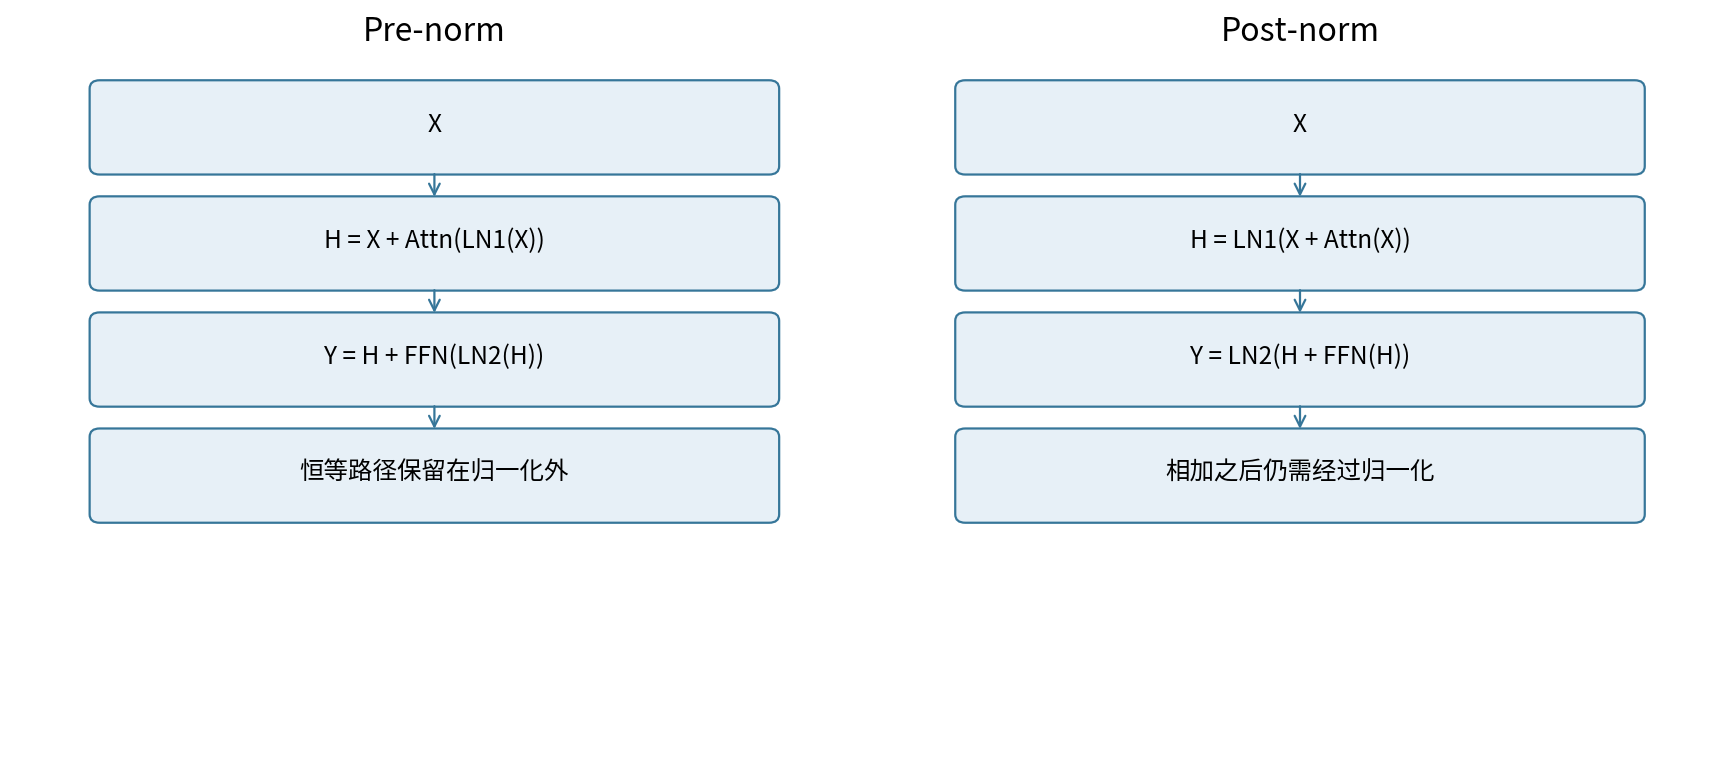

04_positions.png


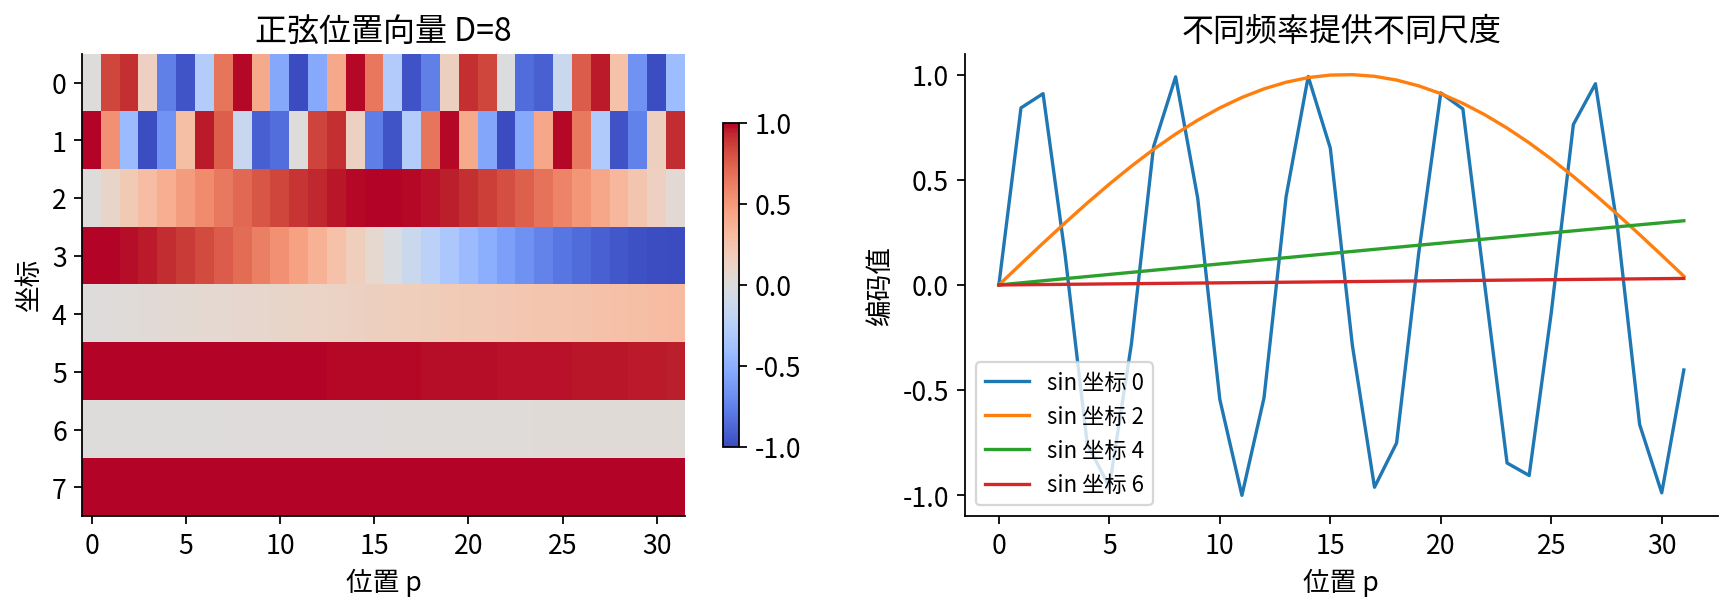

05_rope.png


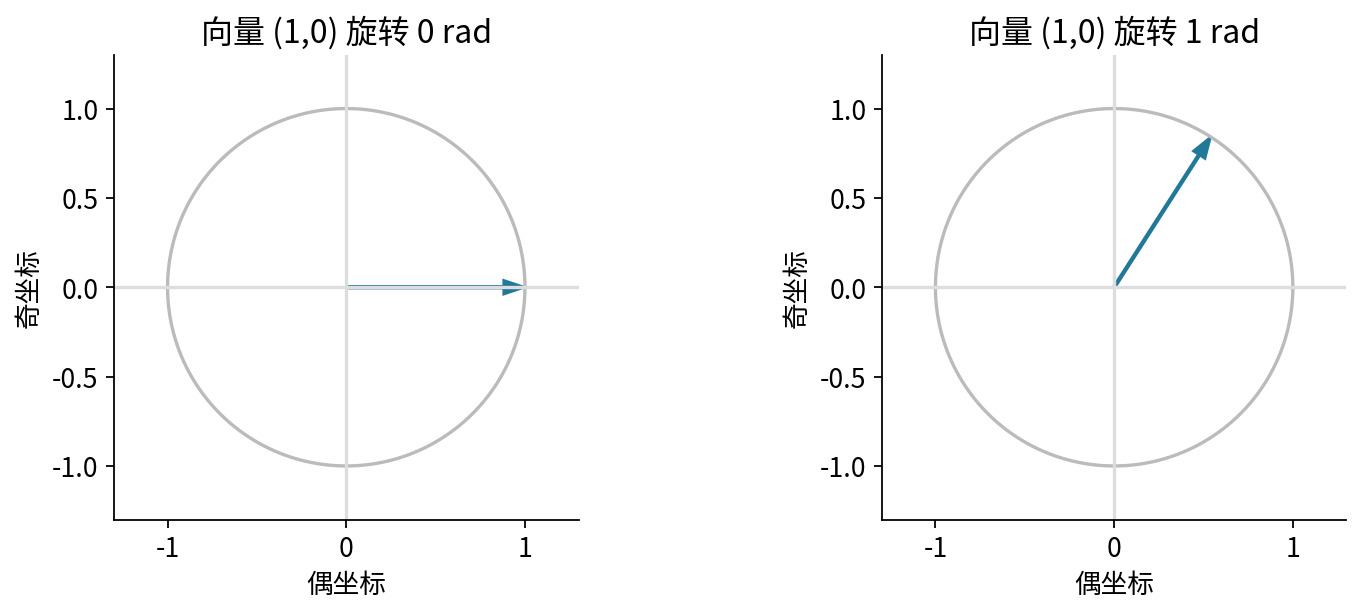

06_invariants.png


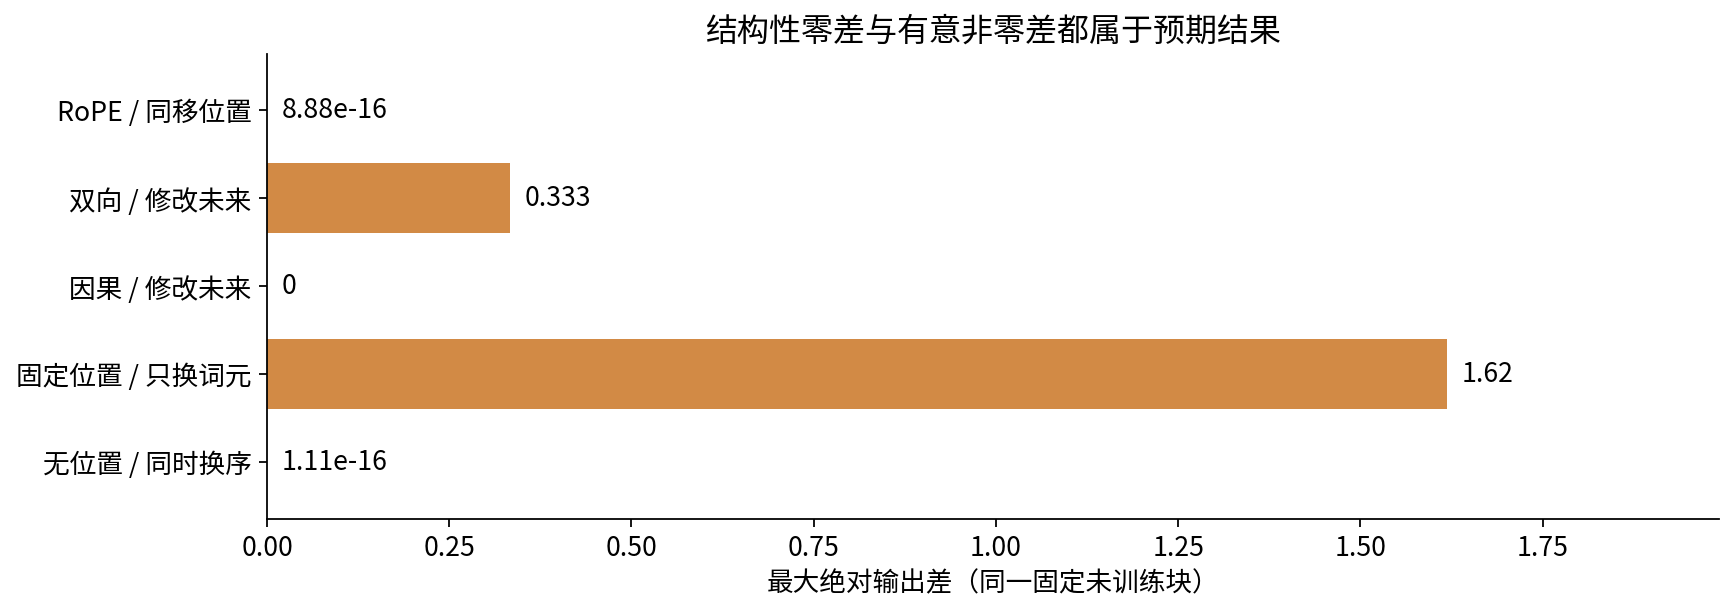

07_hand.png


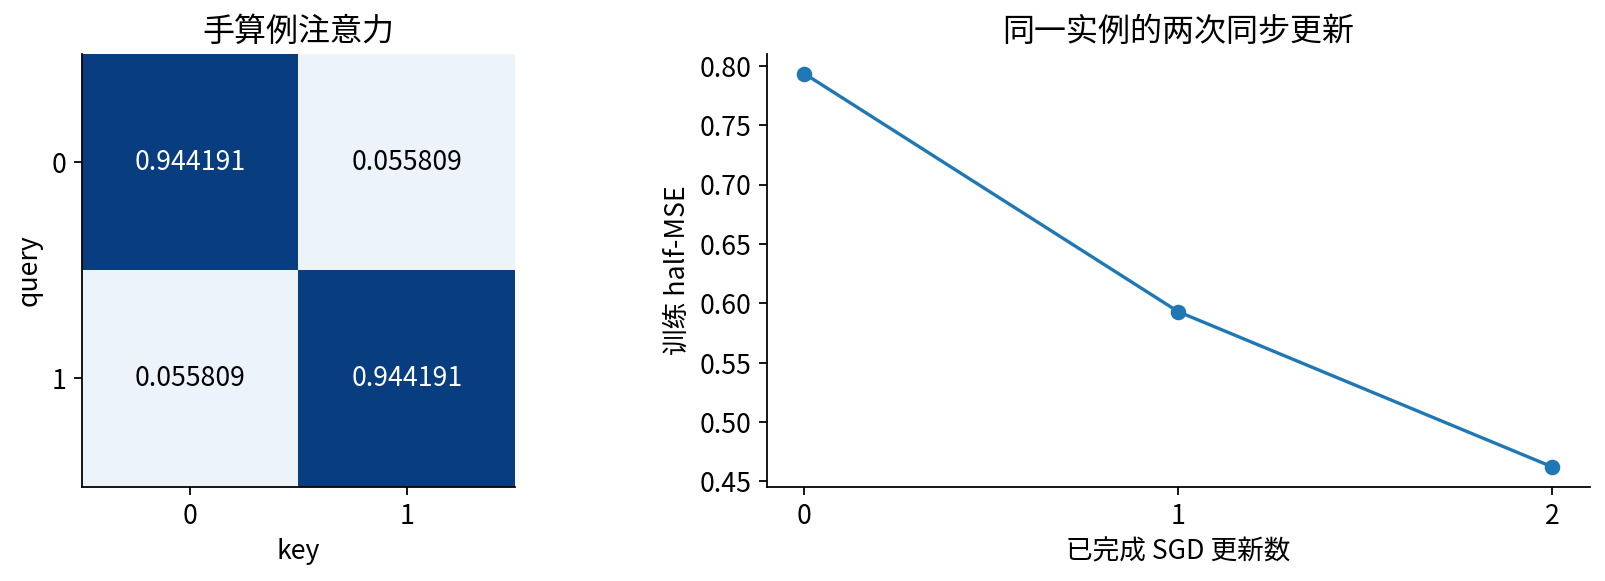

In [6]:
from make_figures import main as draw
from IPython.display import display, Image
directory=draw(REPLAY/"results.json",REPLAY/"figures")
for path in sorted(directory.glob("*.png")):
    print(path.name)
    display(Image(filename=str(path)))

## 6 写下证据边界
请回答：为什么双向长度变化不应强求零差？为什么pre/post对齐都成功不表示性能相同？为什么RoPE共同平移不变不证明无限上下文？答案见answers.pdf。实测为CPU float64、零dropout、有限小张量；未测试GPU、半精度、浏览器UI或任何自然语言能力。